# Illustration Exercise — LLM Foundations

## Context

Transformers are permutation-equivariant: without additional information, the self-attention operation treats tokens in position 1 and position 50 identically. Sinusoidal positional encoding (Definition 3.5 in the chapter) injects positional information by assigning each (position, dimension) pair a unique value based on sine and cosine functions of increasing period. This heatmap makes the encoding matrix visible: rows are token positions, columns are encoding dimensions, and the colour encodes the value in $[-1, 1]$.

## Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import pathlib

plt.style.use(["science", "no-latex"])

def positional_encoding(max_len: int, d_model: int) -> np.ndarray:
    PE = np.zeros((max_len, d_model))
    pos = np.arange(max_len)[:, np.newaxis]
    div = np.exp(np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
    PE[:, 0::2] = np.sin(pos * div)
    n_cos = d_model // 2
    PE[:, 1::2] = np.cos(pos * div[:n_cos])
    return PE

PE = positional_encoding(max_len=50, d_model=64)
print(f"PE shape: {PE.shape}  |  range: [{PE.min():.3f}, {PE.max():.3f}]")

PE shape: (50, 64)  |  range: [-1.000, 1.000]


## Figure

Saved to C:\Users\jfimb\Documents\book-course-template\book\chapters\02-llm-foundations\figures\fig_illustration.pdf


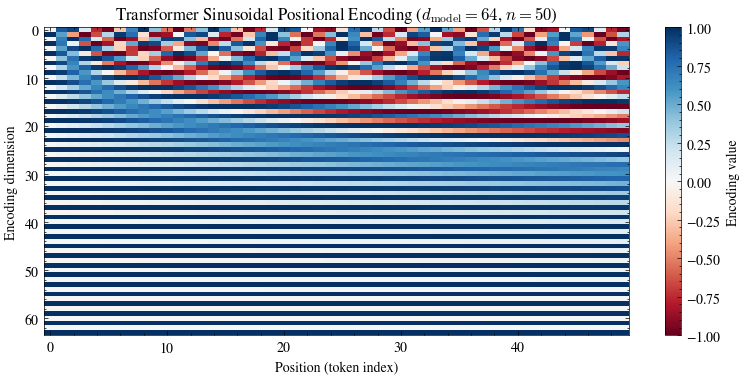

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(PE.T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
ax.set_xlabel("Position (token index)")
ax.set_ylabel("Encoding dimension")
ax.set_title("Transformer Sinusoidal Positional Encoding "
             r"($d_\mathrm{model}=64$, $n=50$)")
plt.colorbar(im, ax=ax, label="Encoding value")
fig.tight_layout()

out_path = pathlib.Path(
    "../../../book/chapters/02-llm-foundations/figures/fig_illustration.pdf"
)
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, bbox_inches="tight", dpi=150)
print(f"Saved to {out_path.resolve()}")
plt.show()

## Your Turn

Repeat the heatmap for $d_{\text{model}} \in \{32, 128\}$ and sequence length 100.
Then extract the encoding vectors for positions 5 and 10 from the $d=64$ matrix
and compute their cosine similarity. Compare it to the cosine similarity between
positions 5 and 45. What does this tell you about how well the encoding preserves
relative distance information?

# Chapter 2 Exercises: Large Language Models — Architecture and Practice

This notebook contains the exercises for Chapter 2 of *Large Language Models in Finance*.
See `course/lectures/02-llm-foundations/exercises.md` for the full problem statements.